# 1. Imports


In [51]:
import random
import numpy as np
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from geopy.distance import geodesic
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. Configuration


In [2]:
OD_PAIRS_COUNT = 20
ROUTES_PER_OD = 200

THETA_MIN = 0.2
THETA_MAX = 2.0

N_CLUSTERS = 4
EXAMPLE_OD = 3

API_URL = "http://localhost:8080/api/route"

EXAMPLE_START = (48.18051, 16.33375)
EXAMPLE_END = (48.23336, 16.37512)

# 3. Load Vienna Boundary


In [3]:
vienna = gpd.read_file("resources/vienna.json")
vienna_polygon = vienna.geometry.union_all()

minx, miny, maxx, maxy = vienna.total_bounds

print(f"West:  {minx}")
print(f"South: {miny}")
print(f"East:  {maxx}")
print(f"North: {maxy}")

vienna_center = [
    (miny + maxy) / 2,
    (minx + maxx) / 2,
]

vienna_map = folium.Map(
    location=vienna_center,
    zoom_start=11,
)

folium.GeoJson(vienna.geometry.to_json()).add_to(vienna_map)

vienna_map

West:  16.18183038
South: 48.11790335
East:  16.57751413
North: 48.32266666


# 4. Origin-Destination Pair Sampling


In [4]:
def sample_point_in_polygon(polygon):
    """Sample one random Point inside a polygon by rejection sampling."""
    minx, miny, maxx, maxy = polygon.bounds

    while True:
        point = Point(
            random.uniform(minx, maxx),
            random.uniform(miny, maxy),
        )

        if polygon.contains(point):
            return point


def sample_od_pair(polygon, min_distance_km=2, max_distance_km=10):
    """Sample one origin-destination pair fully contained in the polygon."""
    origin_point = sample_point_in_polygon(polygon)

    origin_lat = origin_point.y
    origin_lon = origin_point.x

    distance_km = random.uniform(min_distance_km, max_distance_km)
    bearing = random.uniform(0, 360)

    destination = geodesic(kilometers=distance_km).destination(
        (origin_lat, origin_lon),
        bearing,
    )

    destination_point = Point(destination.longitude, destination.latitude)

    if polygon.contains(destination_point):
        return origin_point, destination_point

    return sample_od_pair(
        polygon,
        min_distance_km=min_distance_km,
        max_distance_km=max_distance_km,
    )


def generate_od_pairs(polygon, count):
    """Generate a list of origin-destination point pairs."""
    od_pairs = []

    while len(od_pairs) < count:
        od_pairs.append(sample_od_pair(polygon))

    return od_pairs


def point_to_lat_lon(point):
    """Convert a shapely Point with x=lon, y=lat to a (lat, lon) tuple."""
    return point.y, point.x



In [5]:
od_pairs = generate_od_pairs(
    polygon=vienna_polygon,
    count=OD_PAIRS_COUNT,
)

len(od_pairs)

20

In [6]:
od_map = folium.Map(
    location=vienna_center,
    zoom_start=11,
)

folium.GeoJson(vienna.geometry.to_json()).add_to(od_map)

for od_id, (origin_point, destination_point) in enumerate(od_pairs):
    folium.CircleMarker(
        location=[origin_point.y, origin_point.x],
        radius=3,
        color="green",
        fill=True,
        fill_opacity=0.8,
        popup=f"origin {od_id}",
    ).add_to(od_map)

    folium.CircleMarker(
        location=[destination_point.y, destination_point.x],
        radius=3,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"destination {od_id}",
    ).add_to(od_map)

    folium.PolyLine(
        locations=[
            [origin_point.y, origin_point.x],
            [destination_point.y, destination_point.x],
        ],
        color="blue",
        weight=2,
        opacity=0.5,
    ).add_to(od_map)

od_map

# 5. Routing API


In [7]:
def get_route(origin, destination, theta):
    """Request a route for one origin-destination pair and one preference vector."""
    payload = {
        "points": [
            {
                "lat": origin[0],
                "lon": origin[1],
            },
            {
                "lat": destination[0],
                "lon": destination[1],
            },
        ],
        "profile": "BASE",
        "mode": "CUSTOM",
        "withInstructions": False,
        "preferencesDto": theta,
    }

    response = requests.post(
        API_URL,
        json=payload,
    )

    response.raise_for_status()

    return response.json()



# 6. Preference Vectors


In [8]:
def route_params(
    cycleway_lane=1.0,
    cycleway_track=1.0,
    road_class_cycleway=1.0,
    road_class_primary_secondary_trunk=1.0,
    road_class_residential=1.0,
    road_class_path=1.0,
    road_class_footway=1.0,
    surface_cobblestone_gravel_unpaved=1.0,
    incline_avg_above_four_percent=1.0,
    decline_avg_above_four_percent=1.0,
    no_car_access=1.0,
    bike_road_access_designated=1.0,
    bike_road_access_dismount_or_get_off_bike=1.0,
    max_speed_above_thirty=1.0,
):
    """Create a routing preference vector in API field naming."""
    return {
        "cyclewayLane": cycleway_lane,
        "cyclewayTrack": cycleway_track,
        "roadClassCycleway": road_class_cycleway,
        "roadClassPrimarySecondaryTrunk": road_class_primary_secondary_trunk,
        "roadClassResidential": road_class_residential,
        "roadClassPath": road_class_path,
        "roadClassFootway": road_class_footway,
        "surfaceCobblestoneGravelUnpaved": surface_cobblestone_gravel_unpaved,
        "inclineAvgAboveFourPercent": incline_avg_above_four_percent,
        "declineAvgAboveFourPercent": decline_avg_above_four_percent,
        "noCarAccess": no_car_access,
        "bikeRoadAccessDesignated": bike_road_access_designated,
        "bikeRoadAccessDismountOrGetOffBike": bike_road_access_dismount_or_get_off_bike,
        "maxSpeedAboveThirty": max_speed_above_thirty,
    }


BASE_THETA = route_params()

SAFE_THETA = route_params(
    road_class_cycleway=1.5,
    # no_car_access=1.5,
    # road_class_primary_secondary_trunk=0.5,
    # max_speed_above_thirty=0.5,
)

In [9]:
def sample_theta(theta_min=THETA_MIN, theta_max=THETA_MAX):
    """Sample one random routing preference vector."""
    return route_params(
        cycleway_lane=random.uniform(theta_min, theta_max),
        cycleway_track=random.uniform(theta_min, theta_max),
        road_class_cycleway=random.uniform(theta_min, theta_max),
        road_class_primary_secondary_trunk=random.uniform(theta_min, theta_max),
        road_class_residential=random.uniform(theta_min, theta_max),
        road_class_path=random.uniform(theta_min, theta_max),
        road_class_footway=random.uniform(theta_min, theta_max),
        surface_cobblestone_gravel_unpaved=random.uniform(theta_min, theta_max),
        incline_avg_above_four_percent=random.uniform(theta_min, theta_max),
        decline_avg_above_four_percent=random.uniform(theta_min, theta_max),
        no_car_access=random.uniform(theta_min, theta_max),
        bike_road_access_designated=random.uniform(theta_min, theta_max),
        bike_road_access_dismount_or_get_off_bike=random.uniform(theta_min, theta_max),
        max_speed_above_thirty=random.uniform(theta_min, theta_max),
    )



# 7. Feature Extraction and Distance Metrics


In [10]:
def extract_feature_vector(route):
    """Flatten routeFeatures into one feature-share dictionary."""
    feature_vector = {}

    route_features = route["properties"]["routeFeatures"]

    for category, values in route_features.items():
        for value, share in values.items():
            feature_vector[f"{category}:{value}"] = share

    return feature_vector


def l1_distance(features_a, features_b):
    """Compute L1 distance between sparse feature-share dictionaries."""
    feature_keys = set(features_a.keys()) | set(features_b.keys())

    return sum(
        abs(features_a.get(feature, 0) - features_b.get(feature, 0))
        for feature in feature_keys
    )


def route_coordinates(route):
    """Convert GeoJSON [lon, lat] route coordinates to folium-compatible (lat, lon)."""
    return [
        (lat, lon)
        for lon, lat in route["geometry"]["coordinates"]
    ]



# 8. Baseline Example


In [11]:
base_route = get_route(
    EXAMPLE_START,
    EXAMPLE_END,
    BASE_THETA,
)

safe_route = get_route(
    EXAMPLE_START,
    EXAMPLE_END,
    SAFE_THETA,
)

In [12]:
def plot_route_comparison(route_a, route_b, label_a="BASE", label_b="SAFE"):
    """Plot two routes on one folium map."""
    coordinates_a = route_coordinates(route_a)
    coordinates_b = route_coordinates(route_b)

    route_map = folium.Map(
        location=coordinates_a[0],
        zoom_start=14,
    )

    folium.PolyLine(
        coordinates_a,
        color="blue",
        weight=6,
        tooltip=label_a,
    ).add_to(route_map)

    folium.PolyLine(
        coordinates_b,
        color="red",
        weight=4,
        tooltip=label_b,
    ).add_to(route_map)

    return route_map


plot_route_comparison(
    base_route,
    safe_route,
)

In [13]:
base_features = extract_feature_vector(base_route)
safe_features = extract_feature_vector(safe_route)

comparison_df = pd.DataFrame({
    "BASE": base_features,
    "SAFE": safe_features,
}).fillna(0)

comparison_df

,BASE,SAFE
bike_network:regional,0.487085,0.507299
bike_network:local,0.095941,0.131387
surface:concrete,0.011070,0.010949
surface:asphalt,0.974170,0.974453
surface:paved,0.011070,0.010949
max_speed:50.0,0.055351,0.047445
max_speed:30.0,0.173432,0.124088
road_class:secondary,0.011070,0.010949
road_class:residential,0.121771,0.069343
road_class:service,0.040590,0.040146


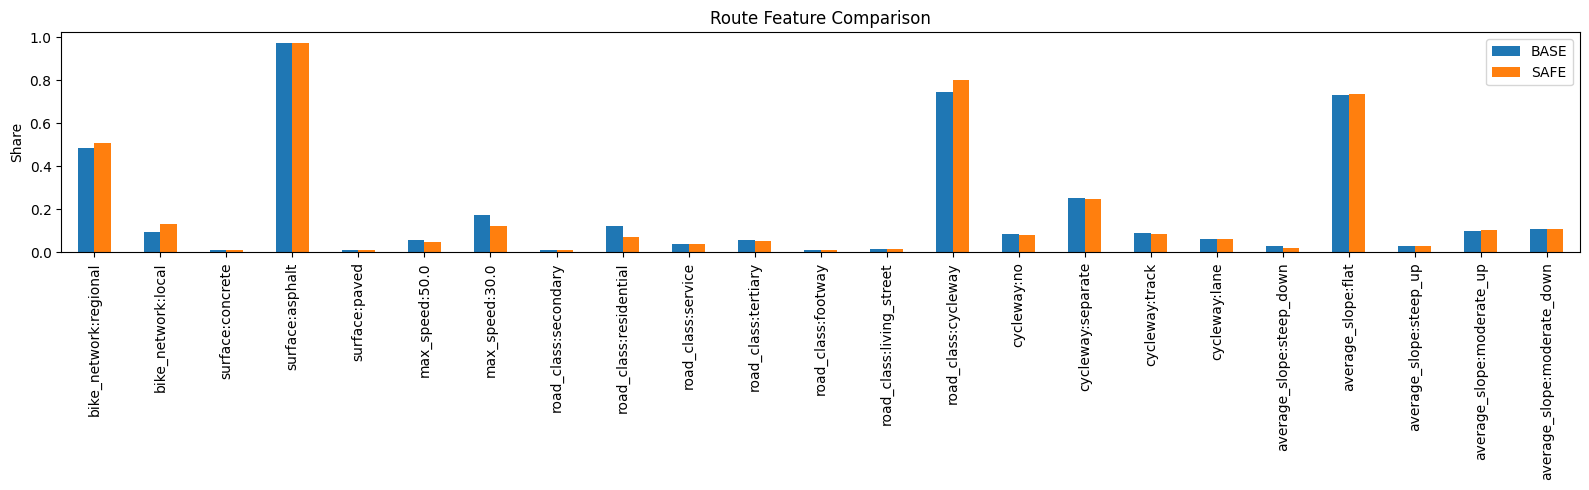

In [14]:
comparison_df.plot(
    kind="bar",
    figsize=(16, 5),
)

plt.ylabel("Share")
plt.title("Route Feature Comparison")
plt.tight_layout()
plt.show()

In [15]:
absolute_feature_difference = (
    comparison_df["BASE"]
    .sub(comparison_df["SAFE"])
    .abs()
)

absolute_feature_difference.sort_values(ascending=False)

road_class:cycleway            0.057532
road_class:residential         0.052428
max_speed:30.0                 0.049344
bike_network:local             0.035446
bike_network:regional          0.020214
max_speed:50.0                 0.007905
average_slope:steep_down       0.007622
average_slope:flat             0.006599
cycleway:no                    0.004579
road_class:tertiary            0.004256
cycleway:separate              0.002747
average_slope:moderate_up      0.002559
average_slope:moderate_down    0.001212
cycleway:track                 0.000970
cycleway:lane                  0.000687
road_class:service             0.000444
average_slope:steep_up         0.000323
surface:asphalt                0.000283
road_class:living_street       0.000162
road_class:secondary           0.000121
surface:paved                  0.000121
surface:concrete               0.000121
road_class:footway             0.000121
dtype: float64

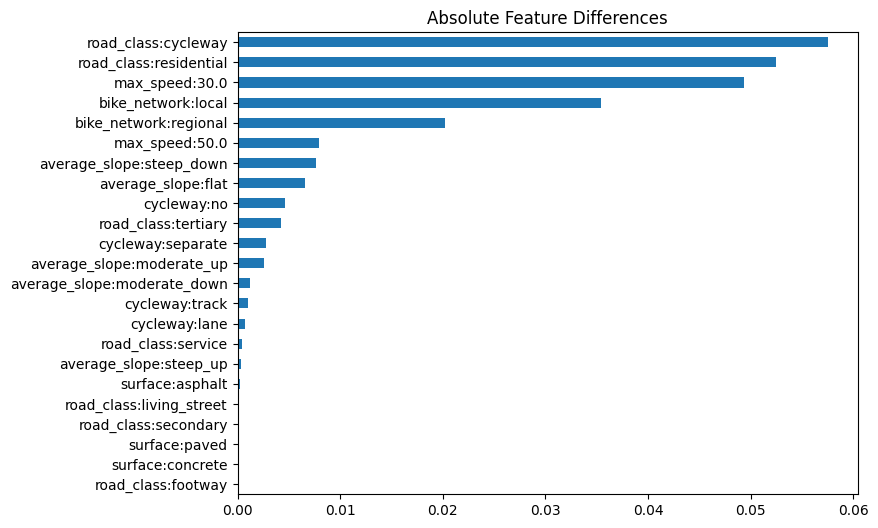

In [16]:
absolute_feature_difference.sort_values().plot.barh(
    figsize=(8, 6),
)

plt.title("Absolute Feature Differences")
plt.show()

In [17]:
example_feature_distance = l1_distance(
    base_features,
    safe_features,
)

print(f"L1 feature distance: {example_feature_distance:.4f}")

L1 feature distance: 0.2558


# 9. Experiment Execution

This section generates the route dataset used in the results chapter.
For each OD pair, one baseline route is generated with BASE_THETA and
additional routes are generated with randomly sampled parameter vectors.

In [18]:
def run_od_experiment(origin, destination, theta):
    """Run one OD experiment and return both the route and its feature vector."""
    candidate_route = get_route(origin, destination, theta)
    candidate_features = extract_feature_vector(candidate_route)

    return candidate_route, candidate_features


def route_metadata(route):
    """Extract route-level metadata from a GraphHopper route response.

    Note:
    route_time_min is assumed to already be returned in minutes.
    """
    properties = route["properties"]

    return {
        "route_length_m": properties.get("distance"),
        "route_time_min": properties.get("time"),
        "route_ascend_m": properties.get("ascend"),
        "route_descend_m": properties.get("descend"),
    }


def make_experiment_row(
    od_id,
    sample_id,
    theta,
    route,
    features,
    feature_distance,
    is_baseline,
):
    """Create one results row from route metadata, parameters, and features."""
    row = {
        "od_id": od_id,
        "sample_id": sample_id,
        "is_baseline": is_baseline,
        **route_metadata(route),
        **theta,
        "feature_distance": feature_distance,
    }

    for feature_name, feature_value in features.items():
        row[feature_name] = feature_value

    return row

In [19]:
experiment_rows = []
route_records = []
base_feature_vectors = {}

for od_id, (origin_point, destination_point) in enumerate(od_pairs):
    origin = point_to_lat_lon(origin_point)
    destination = point_to_lat_lon(destination_point)

    try:
        base_route = get_route(
            origin,
            destination,
            BASE_THETA,
        )
        base_features = extract_feature_vector(base_route)
        base_feature_vectors[od_id] = base_features

        base_row = make_experiment_row(
            od_id=od_id,
            sample_id=-1,
            theta=BASE_THETA,
            route=base_route,
            features=base_features,
            feature_distance=0.0,
            is_baseline=True,
        )

        experiment_rows.append(base_row)
        route_records.append({
            "od_id": od_id,
            "sample_id": -1,
            "is_baseline": True,
            "route": base_route,
        })

        for sample_id in range(ROUTES_PER_OD):
            random_theta = sample_theta()

            candidate_route, candidate_features = run_od_experiment(
                origin,
                destination,
                random_theta,
            )

            feature_distance = l1_distance(
                base_features,
                candidate_features,
            )

            experiment_row = make_experiment_row(
                od_id=od_id,
                sample_id=sample_id,
                theta=random_theta,
                route=candidate_route,
                features=candidate_features,
                feature_distance=feature_distance,
                is_baseline=False,
            )

            experiment_rows.append(experiment_row)
            route_records.append({
                "od_id": od_id,
                "sample_id": sample_id,
                "is_baseline": False,
                "route": candidate_route,
            })

    except Exception as error:
        print(f"failed OD {od_id}: {error}")

# 10. Results Dataset

This section constructs the main results dataframe and defines reusable
column groups for the following analysis.

In [20]:
results_df = pd.DataFrame(experiment_rows)
route_records_df = pd.DataFrame(route_records)

PARAMETER_COLUMNS = list(BASE_THETA.keys())

METADATA_COLUMNS = [
    "od_id",
    "sample_id",
    "is_baseline",
    "route_length_m",
    "route_time_min",
    "route_ascend_m",
    "route_descend_m",
    "feature_distance",
]

FEATURE_COLUMNS = [
    column
    for column in results_df.columns
    if column not in METADATA_COLUMNS
    and column not in PARAMETER_COLUMNS
]

results_df[FEATURE_COLUMNS] = (
    results_df[FEATURE_COLUMNS]
    .fillna(0)
)

results_df.head()

,od_id,sample_id,is_baseline,route_length_m,route_time_min,route_ascend_m,route_descend_m,cyclewayLane,cyclewayTrack,roadClassCycleway,...,road_class:steps,surface:fine_gravel,surface:unpaved,surface:dirt,max_speed:40.0,surface:wood,max_speed:70.0,max_speed:8.0,surface:other,max_speed:100.0
0,0,-1,True,8649.966,31.469683,144.36057,82.0,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,False,10258.386,39.893833,206.36057,144.0,1.551502,1.697609,0.994787,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,False,9066.177,34.100683,154.36057,92.0,1.528643,1.944780,1.875217,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2,False,10500.468,39.362767,167.36057,105.0,1.349424,1.212986,1.896636,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,False,9023.862,45.096000,150.36057,88.0,1.122820,1.834619,0.265415,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
dataset_overview = pd.Series({
    "od_pairs": results_df["od_id"].nunique(),
    "routes_total": len(results_df),
    "baseline_routes": results_df["is_baseline"].sum(),
    "sampled_routes": (~results_df["is_baseline"]).sum(),
    "features": len(FEATURE_COLUMNS),
    "parameters": len(PARAMETER_COLUMNS),
})

dataset_overview

od_pairs             20
routes_total       2020
baseline_routes      20
sampled_routes     2000
features             50
parameters           14
dtype: int64

In [22]:
# todo this is useless

route_length_time_summary = results_df[
    [
        "route_length_m",
        "route_time_min",
        "route_ascend_m",
        "route_descend_m",
        "feature_distance",
    ]
].describe()

route_length_time_summary

,route_length_m,route_time_min,route_ascend_m,route_descend_m,feature_distance
count,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000
mean,10253.312509,43.669194,194.899058,190.752458,1.801702
std,5417.547406,25.762409,163.917982,157.430371,0.997737
min,3122.523000,13.353883,36.098238,26.000000,0.000000
25%,5773.275000,22.385121,79.725495,90.000000,1.017554
50%,9796.915500,38.550517,135.002731,137.700789,1.759530
75%,13101.166250,55.812021,261.968763,225.992493,2.601674
max,35797.661000,170.005267,1042.000000,977.000000,4.763860


# 11. Feature Variability

This section follows the thesis structure for the feature variability results:

1. Visual example of one OD pair and selected routes.
2. Feature ranges for three example OD pairs.
3. Aggregate feature variability across all OD pairs.
4. Heatmap of feature variability.
5. L1 distance summaries.

## Selecting example OD pairs

In [23]:
feature_std_by_od_df = (
    results_df
    .groupby("od_id")[FEATURE_COLUMNS]
    .std()
    .fillna(0)
)

mean_feature_std_by_od = (
    feature_std_by_od_df
    .mean(axis=1)
    .sort_values()
)

MAP_OD_ID = int(mean_feature_std_by_od.idxmax())

MAP_OD_ID

10

In [24]:
def select_low_medium_high_od_ids(score_by_od):
    """Select low-, medium-, and high-variability OD pairs."""
    sorted_scores = score_by_od.sort_values()

    low_od = int(sorted_scores.index[0])
    medium_od = int(sorted_scores.index[len(sorted_scores) // 2])
    high_od = int(sorted_scores.index[-1])

    selected = []
    for od_id in [low_od, medium_od, high_od]:
        if od_id not in selected:
            selected.append(od_id)

    return selected


EXAMPLE_OD_IDS = select_low_medium_high_od_ids(mean_feature_std_by_od)

EXAMPLE_OD_IDS

[3, 7, 10]

## Visualize example routes

In [25]:
def get_route_from_records(od_id, sample_id):
    """Return the stored route geometry for a given OD pair and sample ID."""
    matches = route_records_df[
        (route_records_df["od_id"] == od_id)
        & (route_records_df["sample_id"] == sample_id)
    ]

    if matches.empty:
        raise ValueError(f"No route found for od_id={od_id}, sample_id={sample_id}")

    return matches.iloc[0]["route"]


def selected_routes_for_map(od_id, top_n=5):
    """Select baseline plus top-N routes by L1 feature distance for one OD pair."""
    od_df = results_df[
        results_df["od_id"] == od_id
    ]

    baseline_row = od_df[
        od_df["is_baseline"]
    ].iloc[0]

    top_rows = (
        od_df[
            ~od_df["is_baseline"]
        ]
        .sort_values("feature_distance", ascending=False)
        .head(top_n)
    )

    selected_rows = pd.concat([
        baseline_row.to_frame().T,
        top_rows,
    ])

    selected_routes = []

    for _, row in selected_rows.iterrows():
        route = get_route_from_records(
            od_id=int(row["od_id"]),
            sample_id=int(row["sample_id"]),
        )

        selected_routes.append({
            "label": (
                "baseline"
                if row["is_baseline"]
                else f"sample {int(row['sample_id'])}"
            ),
            "feature_distance": row["feature_distance"],
            "route": route,
        })

    return selected_routes


def plot_route_overlay(selected_routes):
    """Plot selected routes on one folium map."""
    first_route_coordinates = route_coordinates(selected_routes[0]["route"])

    route_map = folium.Map(
        location=first_route_coordinates[0],
        zoom_start=13,
    )

    colors = ["blue", "red", "green", "purple", "orange", "black"]

    for route_id, route_record in enumerate(selected_routes):
        coordinates = route_coordinates(route_record["route"])

        tooltip = (
            f"{route_record['label']} "
            f"(L1={route_record['feature_distance']:.3f})"
        )

        folium.PolyLine(
            coordinates,
            color=colors[route_id % len(colors)],
            weight=4 if route_record["label"] == "baseline" else 3,
            opacity=0.8,
            tooltip=tooltip,
        ).add_to(route_map)

    return route_map

In [26]:
map_routes = selected_routes_for_map(
    od_id=MAP_OD_ID,
    top_n=5,
)

plot_route_overlay(map_routes)

## Feature Ranges for example OD pairs

In [89]:
def behavior_space_for_od(od_id):
    """Compute min, mean, max, baseline, and range per feature for one OD pair."""
    od_df = results_df[
        results_df["od_id"] == od_id
    ]

    base_features = base_feature_vectors[od_id]

    behavior_space_df = pd.DataFrame({
        "min_share": od_df[FEATURE_COLUMNS].min(),
        "mean_share": od_df[FEATURE_COLUMNS].mean(),
        "max_share": od_df[FEATURE_COLUMNS].max(),
    })

    behavior_space_df["base_share"] = [
        base_features.get(feature, 0)
        for feature in behavior_space_df.index
    ]

    behavior_space_df["range"] = (
        behavior_space_df["max_share"]
        - behavior_space_df["min_share"]
    )

    behavior_space_df = (
        behavior_space_df
        .sort_values("range", ascending=False)
    )

    return behavior_space_df


def plot_behavior_space_dots(od_id, top_n=15):
    """Plot sampled feature values with baseline marker for one OD pair."""
    behavior_space_df = behavior_space_for_od(od_id)
    top_features = behavior_space_df.head(top_n).index.tolist()

    od_samples_df = results_df[results_df["od_id"] == od_id]

    plt.figure(figsize=(10, 8))

    for y_pos, feature in enumerate(top_features):

        sample_values = od_samples_df[feature].dropna()
    
        # background range
        plt.hlines(
            y=y_pos,
            xmin=sample_values.min(),
            xmax=sample_values.max(),
            alpha=0.2,
            linewidth=4,
            zorder=1,
        )
    
        # sampled routes
        plt.scatter(
            sample_values,
            np.full(len(sample_values), y_pos),
            alpha=0.5,
            s=20,
            zorder=2,
            label="Sample Routes" if y_pos == 0 else None,
        )
    
        # baseline
        plt.scatter(
            behavior_space_df.loc[feature, "base_share"],
            y_pos,
            s=60,
            edgecolor="black",
            linewidth=1.5,
            zorder=3,
            label="Baseline Route" if y_pos == 0 else None,
        )

    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel("Feature Share")
    plt.title(f"Reachable Behavior Space Distribution (OD {od_id})")
    plt.legend()
    plt.show()

    return behavior_space_df

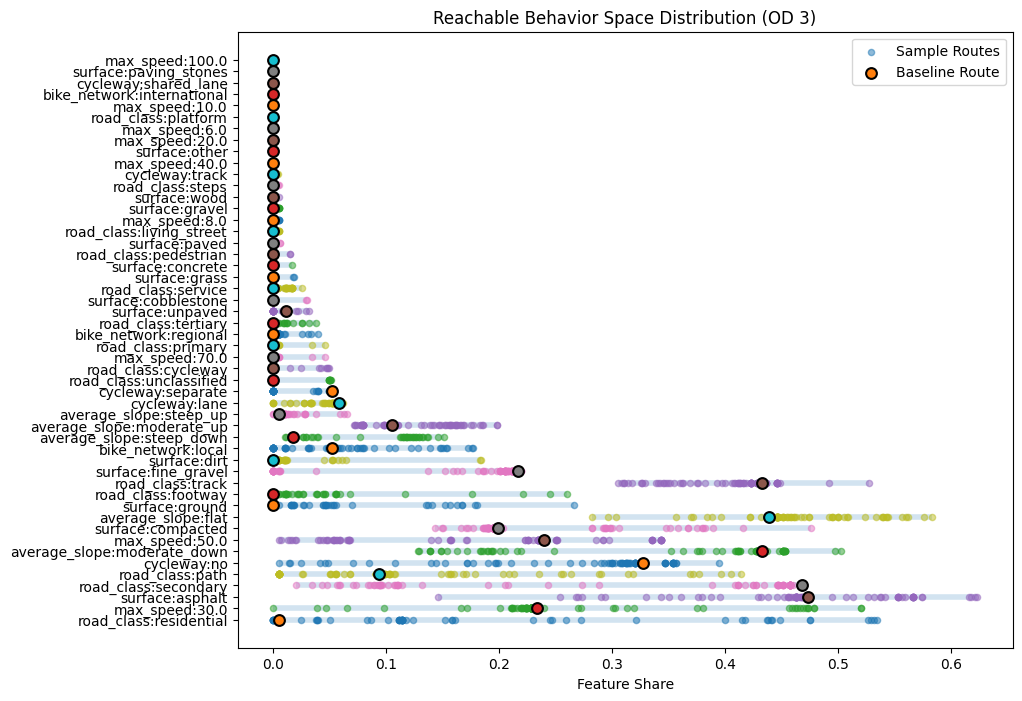

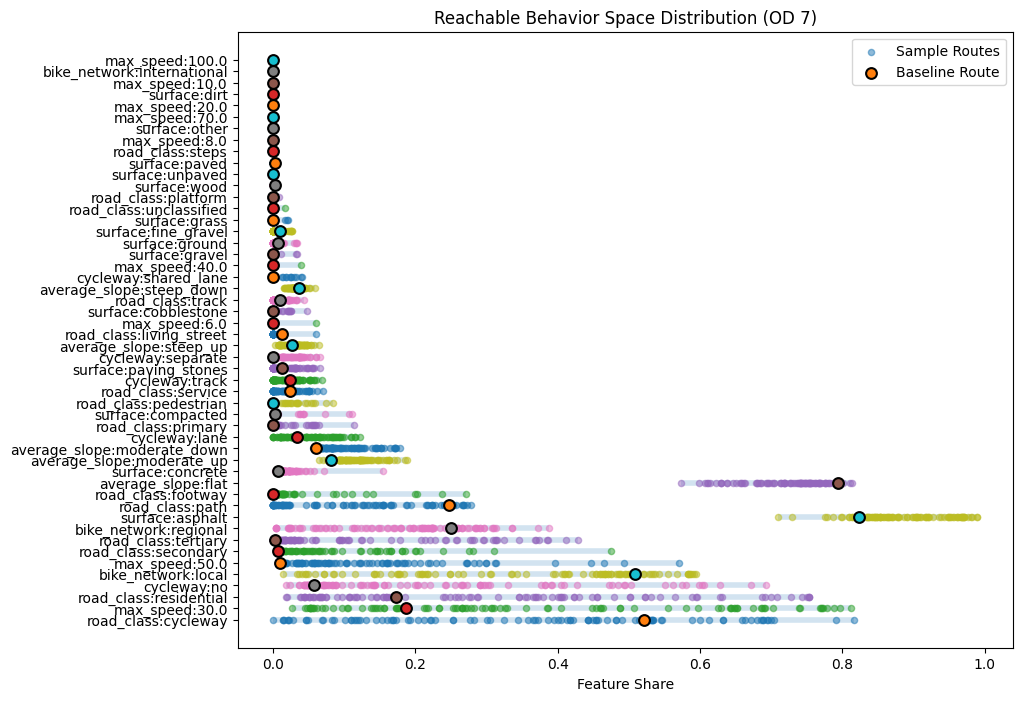

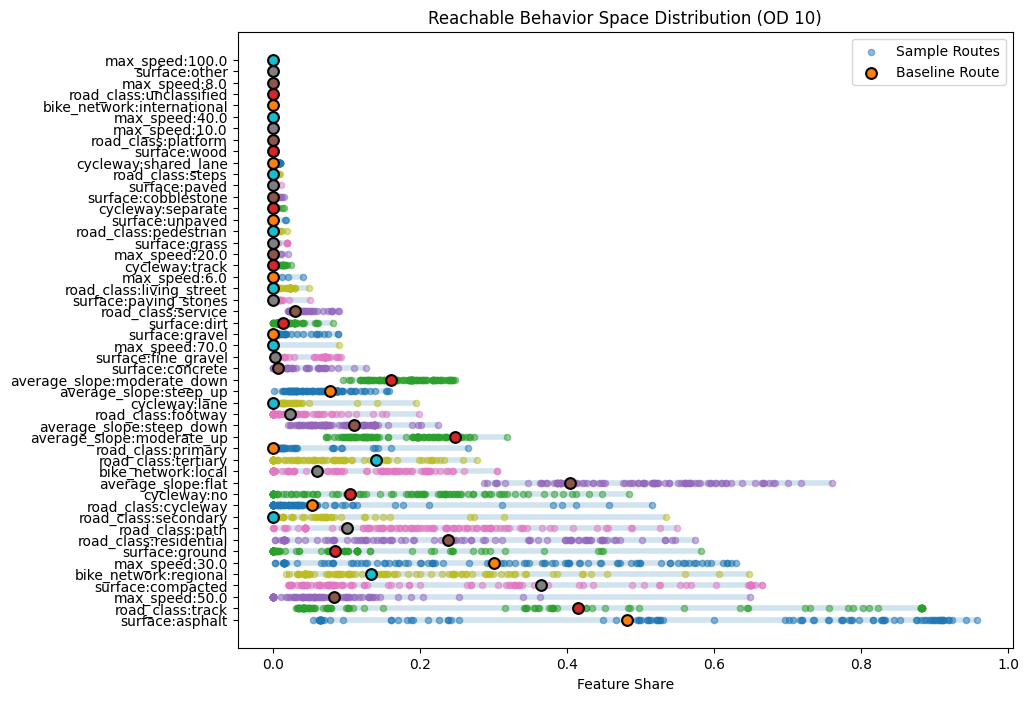

In [91]:
example_behavior_spaces = {}

for od_id in EXAMPLE_OD_IDS:
    example_behavior_spaces[od_id] = plot_behavior_space_dots(
        od_id=od_id,
        top_n=50,
    )

# todo decide on feature order, make consist across plots
# maybe dont show lines but instead points for every sample route

In [48]:
# Optional: inspect the table behind one example plot.
example_behavior_spaces[EXAMPLE_OD_IDS[-1]].head(20)

,min_share,mean_share,max_share,base_share,range
surface:asphalt,0.054441,0.544275,0.958412,0.481651,0.903971
road_class:track,0.030857,0.319400,0.882698,0.415138,0.851841
max_speed:50.0,0.000000,0.067739,0.649502,0.082569,0.649502
surface:compacted,0.020472,0.250845,0.665689,0.364679,0.645217
bike_network:regional,0.018272,0.171298,0.648038,0.133028,0.629766
max_speed:30.0,0.002865,0.279042,0.629816,0.300459,0.626950
surface:ground,0.000000,0.085234,0.582781,0.084862,0.582781
road_class:residential,0.002865,0.230394,0.574730,0.238532,0.571865
road_class:path,0.000000,0.205246,0.550489,0.100917,0.550489
road_class:secondary,0.000000,0.035677,0.534884,0.000000,0.534884


## Feature variability across all OD pairs

In [30]:
behavior_rows = []

for od_id in sorted(results_df["od_id"].unique()):
    od_df = results_df[
        results_df["od_id"] == od_id
    ]

    base_features = base_feature_vectors[od_id]

    od_behavior_space_df = pd.DataFrame({
        "min_share": od_df[FEATURE_COLUMNS].min(),
        "mean_share": od_df[FEATURE_COLUMNS].mean(),
        "max_share": od_df[FEATURE_COLUMNS].max(),
    })

    od_behavior_space_df["base_share"] = [
        base_features.get(feature, 0)
        for feature in od_behavior_space_df.index
    ]

    od_behavior_space_df["range"] = (
        od_behavior_space_df["max_share"]
        - od_behavior_space_df["min_share"]
    )

    od_behavior_space_df["mean_delta_to_base"] = (
        od_behavior_space_df["mean_share"]
        - od_behavior_space_df["base_share"]
    )

    mean_abs_delta_to_base = {}

    for feature in FEATURE_COLUMNS:
        base_value = base_features.get(feature, 0)
        mean_abs_delta_to_base[feature] = (
            od_df[feature]
            .sub(base_value)
            .abs()
            .mean()
        )

    od_behavior_space_df["mean_abs_delta_to_base"] = (
        pd.Series(mean_abs_delta_to_base)
    )

    od_behavior_space_df["od_id"] = od_id
    od_behavior_space_df["feature"] = od_behavior_space_df.index

    behavior_rows.append(
        od_behavior_space_df.reset_index(drop=True)
    )


behavior_by_od_df = pd.concat(
    behavior_rows,
    ignore_index=True,
)

behavior_summary_df = (
    behavior_by_od_df
    .groupby("feature")
    .agg({
        "min_share": "mean",
        "base_share": "mean",
        "mean_share": "mean",
        "max_share": "mean",
        "range": "mean",
        "mean_delta_to_base": "mean",
        "mean_abs_delta_to_base": "mean",
    })
    .rename(columns={
        "min_share": "mean_min_share",
        "base_share": "mean_base_share",
        "mean_share": "mean_mean_share",
        "max_share": "mean_max_share",
        "range": "mean_range",
        "mean_delta_to_base": "mean_delta_to_base",
        "mean_abs_delta_to_base": "mean_abs_delta_to_base",
    })
    .sort_values("mean_range", ascending=False)
)

behavior_summary_df

# todo no mean_mean_share

,mean_min_share,mean_base_share,mean_mean_share,mean_max_share,mean_range,mean_delta_to_base,mean_abs_delta_to_base
feature,,,,,,,
road_class:residential,0.019328,0.334221,0.313864,0.730023,0.710695,-0.020357,0.202417
max_speed:30.0,0.028734,0.336083,0.330409,0.713142,0.684408,-0.005674,0.187685
road_class:cycleway,0.016601,0.332367,0.289808,0.682484,0.665884,-0.042558,0.184530
max_speed:50.0,0.009177,0.133620,0.162651,0.581799,0.572623,0.029032,0.106461
bike_network:regional,0.014956,0.203432,0.186200,0.555751,0.540795,-0.017232,0.133792
cycleway:no,0.012489,0.161045,0.179325,0.476604,0.464115,0.018280,0.106691
road_class:secondary,0.001272,0.050553,0.078603,0.432593,0.431321,0.028050,0.067146
road_class:footway,0.002971,0.012463,0.036826,0.390138,0.387166,0.024363,0.030287
surface:asphalt,0.549814,0.807336,0.779306,0.932828,0.383013,-0.028031,0.095528


In [31]:
# Compact thesis table candidate.
behavior_summary_df[
    [
        "mean_min_share",
        "mean_base_share",
        "mean_mean_share",
        "mean_max_share",
        "mean_range",
        "mean_delta_to_base",
        "mean_abs_delta_to_base",
    ]
].head(25)

,mean_min_share,mean_base_share,mean_mean_share,mean_max_share,mean_range,mean_delta_to_base,mean_abs_delta_to_base
feature,,,,,,,
road_class:residential,0.019328,0.334221,0.313864,0.730023,0.710695,-0.020357,0.202417
max_speed:30.0,0.028734,0.336083,0.330409,0.713142,0.684408,-0.005674,0.187685
road_class:cycleway,0.016601,0.332367,0.289808,0.682484,0.665884,-0.042558,0.184530
max_speed:50.0,0.009177,0.133620,0.162651,0.581799,0.572623,0.029032,0.106461
bike_network:regional,0.014956,0.203432,0.186200,0.555751,0.540795,-0.017232,0.133792
cycleway:no,0.012489,0.161045,0.179325,0.476604,0.464115,0.018280,0.106691
road_class:secondary,0.001272,0.050553,0.078603,0.432593,0.431321,0.028050,0.067146
road_class:footway,0.002971,0.012463,0.036826,0.390138,0.387166,0.024363,0.030287
surface:asphalt,0.549814,0.807336,0.779306,0.932828,0.383013,-0.028031,0.095528


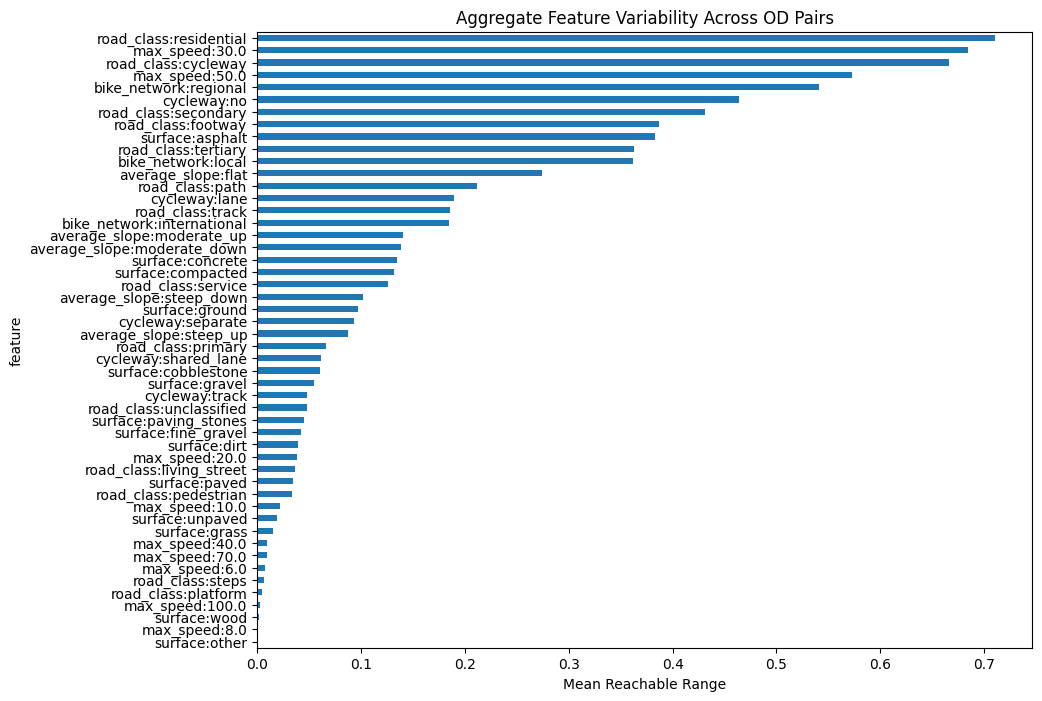

In [32]:
plt.figure(figsize=(10, 8))

behavior_summary_df["mean_range"].sort_values().plot.barh()

plt.xlabel("Mean Reachable Range")
plt.title("Aggregate Feature Variability Across OD Pairs")
plt.show()

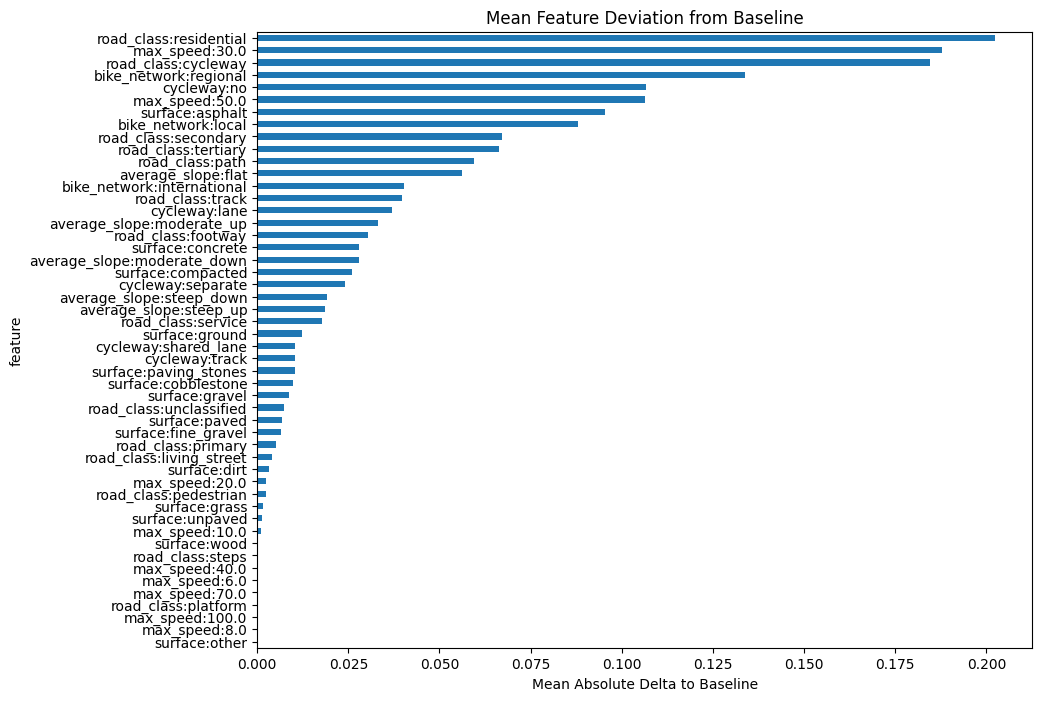

In [33]:
plt.figure(figsize=(10, 8))

behavior_summary_df["mean_abs_delta_to_base"].sort_values().plot.barh()

plt.xlabel("Mean Absolute Delta to Baseline")
plt.title("Mean Feature Deviation from Baseline")
plt.show()

## Heatmap

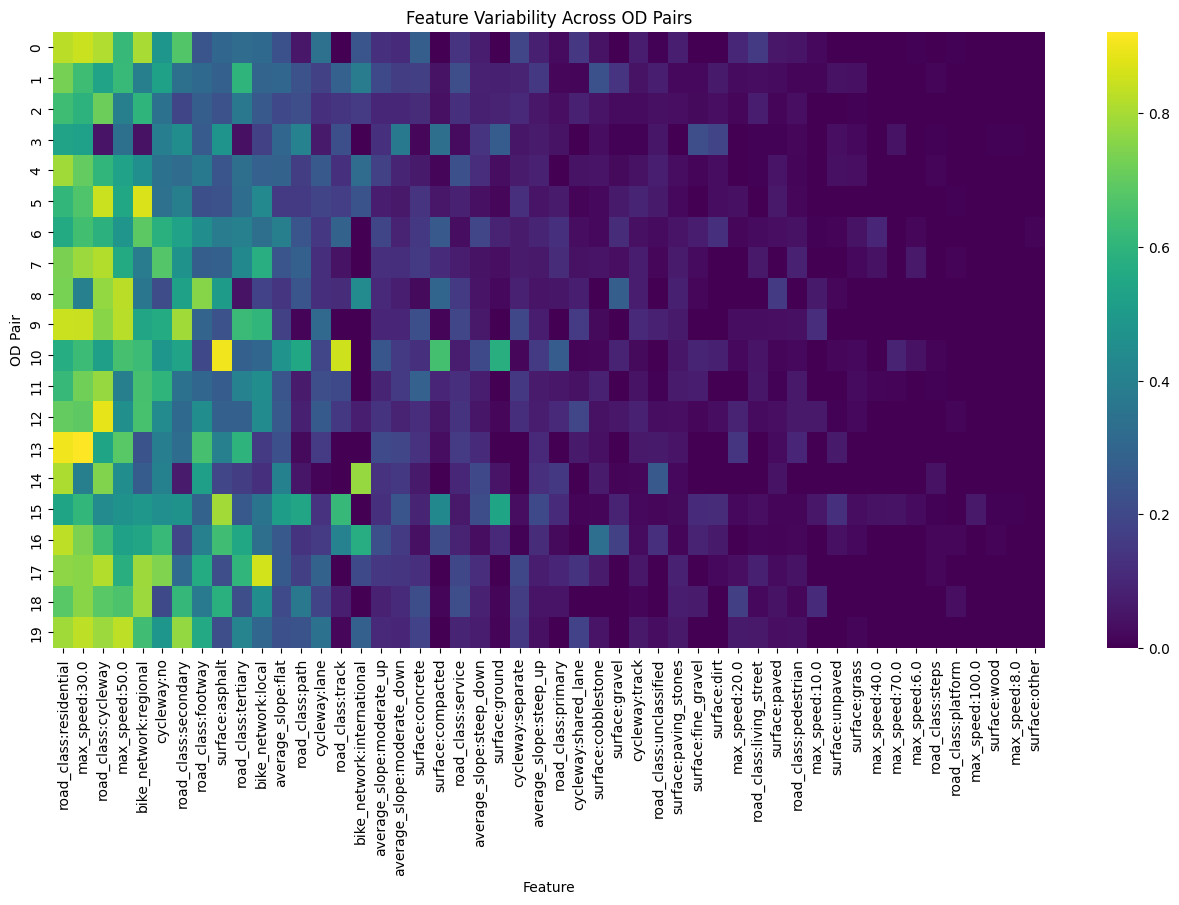

In [34]:
feature_range_matrix = (
    behavior_by_od_df
    .pivot(
        index="od_id",
        columns="feature",
        values="range",
    )
    .fillna(0)
)

# Reorder columns by global mean range.
feature_range_matrix = feature_range_matrix[
    behavior_summary_df.index
]

plt.figure(figsize=(16, 8))

sns.heatmap(
    feature_range_matrix,
    cmap="viridis",
)

plt.xlabel("Feature")
plt.ylabel("OD Pair")
plt.title("Feature Variability Across OD Pairs")
plt.show()

## L1 Distance to Baseline

The current `feature_distance` column stores the L1 distance between each
sampled route feature vector and the baseline feature vector of the same
OD pair. At this stage, the existing feature distance is used as computed
during experiment execution.

TODO: Replace or recompute this with normalized feature vectors once the
final normalization strategy for L1 distance is fixed.

In [35]:
results_df["feature_distance"].describe()

count    2020.000000
mean        1.801702
std         0.997737
min         0.000000
25%         1.017554
50%         1.759530
75%         2.601674
max         4.763860
Name: feature_distance, dtype: float64

In [36]:
l1_summary_by_od_df = (
    results_df
    .groupby("od_id")["feature_distance"]
    .agg(["min", "max", "mean", "std"])
    .sort_values("mean", ascending=False)
)

l1_summary_by_od_df

,min,max,mean,std
od_id,,,,
10,0.0,4.600849,2.362101,0.816578
19,0.0,4.763860,2.276565,1.313068
0,0.0,3.453983,2.175716,0.911415
9,0.0,3.808059,2.149066,1.060616
18,0.0,3.522908,2.071557,1.055423
15,0.0,4.494850,2.062316,1.045017
17,0.0,3.476590,2.033825,0.901413
7,0.0,4.102354,1.895193,1.219321
6,0.0,2.947240,1.865785,0.566281


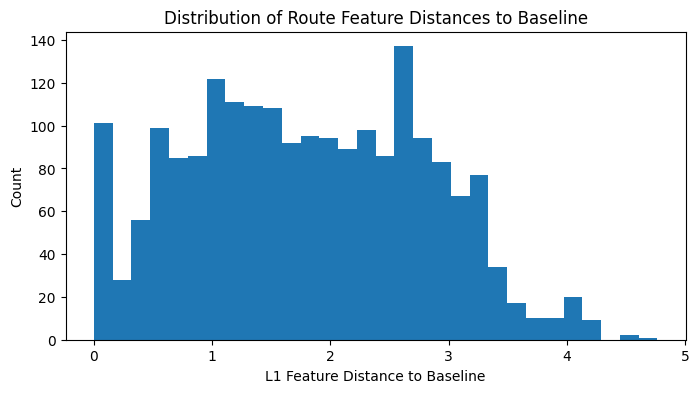

In [37]:
plt.figure(figsize=(8, 4))

plt.hist(
    results_df["feature_distance"],
    bins=30,
)

plt.xlabel("L1 Feature Distance to Baseline")
plt.ylabel("Count")
plt.title("Distribution of Route Feature Distances to Baseline")
plt.show()

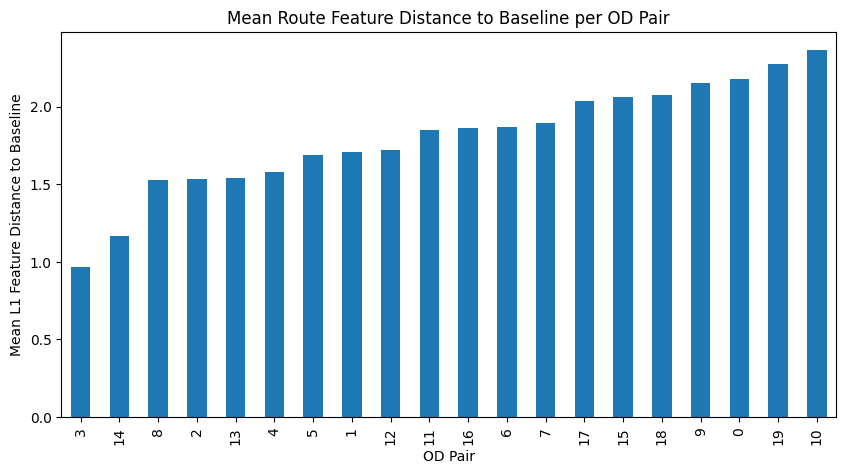

In [38]:
plt.figure(figsize=(10, 5))

l1_summary_by_od_df["mean"].sort_values().plot.bar()

plt.ylabel("Mean L1 Feature Distance to Baseline")
plt.xlabel("OD Pair")
plt.title("Mean Route Feature Distance to Baseline per OD Pair")
plt.show()

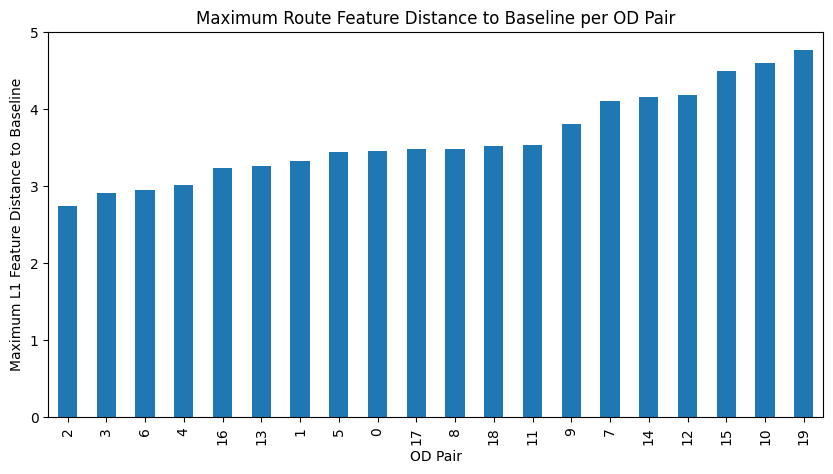

In [39]:
plt.figure(figsize=(10, 5))

l1_summary_by_od_df["max"].sort_values().plot.bar()

plt.ylabel("Maximum L1 Feature Distance to Baseline")
plt.xlabel("OD Pair")
plt.title("Maximum Route Feature Distance to Baseline per OD Pair")
plt.show()

## Route length and time variability

In [40]:
route_metric_summary_df = (
    results_df
    .groupby("od_id")
    .agg({
        "route_length_m": ["min", "max", "mean", "std"],
        "route_time_min": ["min", "max", "mean", "std"],
        "route_ascend_m": ["min", "max", "mean", "std"],
        "route_descend_m": ["min", "max", "mean", "std"],
    })
)

route_metric_summary_df

route_length_m                                       route_time_min  \
                 min        max          mean          std            min   
od_id                                                                       
0           8304.143  13025.368   9374.244089   900.366947      31.469683   
1           9797.334  17826.956  12338.356089  1613.094456      52.492483   
2          11124.970  17014.874  12679.782020  1076.293790      40.996300   
3           5002.956   7109.389   5408.876762   542.472020      18.608783   
4           9622.570  14128.581  11547.054446  1007.518660      45.832617   
5          11930.318  18496.902  13737.692762  1131.052451      42.610267   
6          12404.769  18419.583  14610.063376  1170.310300      56.760667   
7           9241.208  14480.722  10582.596644  1042.401227      34.110600   
8           3272.683   5174.532   4190.533327   510.930681      13.353883   
9           4890.486   8266.734   5998.641208   759.506147      19.241483   
10          8325.793  32782.727  17690.184554  6158.901484      70.784950   
11          5140.404  10447.762   6706.822683  1021.890547      20.523267   
12         12715.439  21157.364  15199.218228  1940.711456      47.698083   
13          3122.523   6803.216   4785.128584   710.692516      15.703317   
14          3917.080   7549.904   4503.069495   724.637029      16.024150   
15         13110.215  35797.661  23231.378089  6470.571146      87.469467   
16          6357.043  12495.949   8344.861782  1437.116021      29.040717   
17          5380.625   7359.589   6066.238228   439.596826      19.811950   
18          4915.260   7617.125   6032.406485   541.926874      19.947567   
19         10886.231  14699.860  12039.101337   938.896598      42.075633   

                                         route_ascend_m               \
              max        mean        std            min          max   
od_id                                                                  
0       54.642117   37.025953   4.681377     137.360570   308.360570   
1       85.154083   63.088845   7.834758     361.000000   604.000000   
2       66.398533   47.708695   5.230918     112.556419   255.166404   
3       34.978717   22.207794   4.468602      75.864556   252.864556   
4       73.750483   53.741308   6.111598     238.412494   354.412494   
5       65.983783   49.953927   4.969295     138.329956   271.830078   
6       96.459650   69.361513   8.665276     211.633604   417.000000   
7       61.327150   39.333759   4.576019      89.875457   167.935516   
8       34.527700   16.434997   2.997724      36.098238    70.098238   
9       35.611383   22.864024   3.038582      83.000000   154.323232   
10     144.527300   89.590884  15.417140     249.834008   581.000000   
11      37.979800   25.381866   3.696525      65.000000   120.725495   
12      81.374133   59.013976   7.195521     109.670829   368.660819   
13      29.793483   18.973165   2.503388      39.463306   109.463306   
14      39.180833   18.157898   5.551526      52.138063   258.698121   
15     170.005267  111.327812  16.295860     435.000000  1042.000000   
16      48.941217   34.834036   5.270682     112.467883   235.467883   
17      40.102383   23.297796   2.986201      75.140822   139.140822   
18      32.563867   24.151906   2.574274      53.035362    89.035362   
19      77.571333   46.933717   5.185234     108.519739   241.259730   

                              route_descend_m                          \
             mean         std             min         max        mean   
od_id                                                                   
0      176.905124   27.640378       75.000000  246.000000  114.544554   
1      435.181387   53.161900      184.000000  427.000000  258.181387   
2      168.548211   35.328905      189.339966  331.949951  245.331757   
3       92.251836   30.327847      211.000000  388.000000  227.387279   
4      288.739253   24.882201      161.000000  277.000000  211.326

# Finding routes that match routing personas

In [43]:
def min_max_normalize(series):
    series_min = series.min()
    series_max = series.max()

    if series_max == series_min:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (
        (series - series_min)
        / (series_max - series_min)
    )


def compute_persona_scores(
    df,
    persona_name,
    positive_features,
    negative_features
):
    scored_df = df.copy()

    score_components = []

    for feature in positive_features:
        score_column = f"{feature}_score"

        scored_df[score_column] = min_max_normalize(
            scored_df[feature]
        )

        score_components.append(score_column)

    for feature in negative_features:
        score_column = f"{feature}_score"

        scored_df[score_column] = (
            1
            - min_max_normalize(scored_df[feature])
        )

        score_components.append(score_column)

    scored_df[f"{persona_name}_score"] = (
        scored_df[score_components]
        .mean(axis=1)
    )

    return scored_df

In [44]:
SAFE_POSITIVE_FEATURES = [
    "cycleway:lane",
    "cycleway:track",
    "road_class:cycleway",
    "road_class:residential",
]

SAFE_NEGATIVE_FEATURES = [
    "cycleway:no",
    "cycleway:shared_lane",
    "road_class:primary",
    "road_class:secondary",
    "max_speed:50.0",
]

SAFE_FEATURES = (
    SAFE_POSITIVE_FEATURES
    + SAFE_NEGATIVE_FEATURES
)

SAFE_SCORE_COLUMNS = [
    f"{feature}_score"
    for feature in SAFE_FEATURES
]

In [45]:
safe_scored_df = compute_persona_scores(
    df=results_df,
    persona_name="safe",
    positive_features=SAFE_POSITIVE_FEATURES,
    negative_features=SAFE_NEGATIVE_FEATURES
)

In [46]:
TOP_N = 5
OD_ID = EXAMPLE_OD

base_route_df = safe_scored_df[
    (safe_scored_df["od_id"] == OD_ID)
    & (safe_scored_df["sample_id"] == -1)
]

top_safe_routes_df = (
    safe_scored_df[
        (safe_scored_df["od_id"] == OD_ID)
        & (safe_scored_df["sample_id"] != -1)
    ]
    .sort_values("safe_score", ascending=False)
    .head(TOP_N)
)

comparison_df = pd.concat(
    [
        base_route_df,
        top_safe_routes_df,
    ],
    ignore_index=True
)

comparison_df[
    [
        "od_id",
        "sample_id",
        "route_length_m",
        "route_time_min",
        *SAFE_FEATURES,
        *SAFE_SCORE_COLUMNS,
        "safe_score",
    ]
]

,od_id,sample_id,route_length_m,route_time_min,cycleway:lane,cycleway:track,road_class:cycleway,road_class:residential,cycleway:no,cycleway:shared_lane,...,cycleway:lane_score,cycleway:track_score,road_class:cycleway_score,road_class:residential_score,cycleway:no_score,cycleway:shared_lane_score,road_class:primary_score,road_class:secondary_score,max_speed:50.0_score,safe_score
0,3,-1,5049.112,18.608783,0.058480,0.0,0.000000,0.005848,0.327485,0.0,...,0.169347,0.0,0.000000,0.006344,0.568183,1.0,1.0,0.409049,0.720661,0.430398
1,3,34,5075.643,27.876783,0.053571,0.0,0.000000,0.160714,0.041667,0.0,...,0.155134,0.0,0.000000,0.174334,0.945059,1.0,1.0,0.924812,0.937587,0.570770
2,3,85,5663.040,25.571267,0.059172,0.0,0.047337,0.272189,0.171598,0.0,...,0.171351,0.0,0.051517,0.295256,0.773734,1.0,1.0,0.880411,0.937956,0.567803
3,3,76,6177.152,28.118900,0.053476,0.0,0.042781,0.229947,0.144385,0.0,...,0.154857,0.0,0.046558,0.249434,0.809616,1.0,1.0,0.891922,0.943928,0.566257
4,3,56,6112.770,27.464150,0.052632,0.0,0.000000,0.436842,0.284211,0.0,...,0.152412,0.0,0.000000,0.473863,0.625245,1.0,1.0,0.893629,0.944813,0.565551
5,3,12,7109.389,31.415233,0.044248,0.0,0.000000,0.438053,0.296460,0.0,...,0.128134,0.0,0.000000,0.475176,0.609092,1.0,1.0,0.910573,0.953604,0.564064


In [47]:
PARAMETER_COLUMNS = [
    "cyclewayLane",
    "cyclewayTrack",
    "roadClassCycleway",
    "roadClassPrimarySecondaryTrunk",
    "roadClassResidential",
    "roadClassPath",
    "roadClassFootway",
    "surfaceCobblestoneGravelUnpaved",
    "inclineAvgAboveFourPercent",
    "declineAvgAboveFourPercent",
    "noCarAccess",
    "bikeRoadAccessDesignated",
    "bikeRoadAccessDismountOrGetOffBike",
    "maxSpeedAboveThirty",
]

top_safe_routes_df[
    [
        "od_id",
        "sample_id",
        "safe_score",
        *PARAMETER_COLUMNS,
    ]
]

,od_id,sample_id,safe_score,cyclewayLane,cyclewayTrack,roadClassCycleway,roadClassPrimarySecondaryTrunk,roadClassResidential,roadClassPath,roadClassFootway,surfaceCobblestoneGravelUnpaved,inclineAvgAboveFourPercent,declineAvgAboveFourPercent,noCarAccess,bikeRoadAccessDesignated,bikeRoadAccessDismountOrGetOffBike,maxSpeedAboveThirty
338,3,34,0.570770,1.785668,0.884328,0.986216,0.579185,1.451970,0.749719,0.225876,1.070234,0.318856,0.252193,1.687087,1.238499,1.642687,1.894091
389,3,85,0.567803,0.813823,0.284863,1.789003,0.633277,1.398036,1.484412,0.998340,0.455039,0.748692,1.151143,1.364115,0.540083,1.242544,0.899926
380,3,76,0.566257,1.945301,1.893546,1.397633,0.334851,1.645549,1.442553,1.561859,0.751678,0.931255,0.297573,0.571498,1.035238,1.147127,1.303278
360,3,56,0.565551,0.270918,1.158456,0.850022,0.838991,1.714279,0.593020,1.555367,1.324198,1.099684,0.644026,1.432205,1.449970,1.060495,0.387404
316,3,12,0.564064,1.330272,1.747318,1.835574,0.585620,1.617476,1.515559,1.348751,0.204719,1.809616,0.245166,1.228226,1.072990,1.465102,0.288231


In [92]:
test_route = get_route(
    EXAMPLE_START,
    EXAMPLE_END,
    BASE_THETA,
)

print(test_route)

{'geometry': {'coordinates': [[16.333575865778062, 48.180493077462614], [16.3334201, 48.1812057], [16.333474, 48.1812025], [16.3341518, 48.181162], [16.334075, 48.1812647], [16.3340334, 48.1813861], [16.3338653, 48.1818761], [16.3337103, 48.1823282], [16.3341234, 48.1824079], [16.3344303, 48.1824941], [16.3348337, 48.1826472], [16.3351329, 48.182767], [16.3359545, 48.1831789], [16.3360828, 48.1832213], [16.3367355, 48.1835326], [16.336817, 48.1835791], [16.3365118, 48.1839377], [16.3362964, 48.1841848], [16.3357917, 48.1847577], [16.3357297, 48.1848262], [16.3358795, 48.1848657], [16.3361952, 48.1850029], [16.3374043, 48.1856221], [16.3374709, 48.1856574], [16.3371618, 48.1860518], [16.3371433, 48.1861009], [16.3371433, 48.1861326], [16.3371661, 48.1861984], [16.3371925, 48.1862323], [16.3375654, 48.1865179], [16.3376036, 48.1865845], [16.3376709, 48.1866569], [16.3378506, 48.18675], [16.3380427, 48.1871381], [16.3381851, 48.1874065], [16.338176, 48.1877201], [16.3381934, 48.1878265], 